Đang quét 20000 seeds để tìm biểu đồ giống hình...
🎉 Đã tìm thấy Seed tiềm năng: 639
 - Đáy: 0.35 tại năm 8.18
 - Giá kết thúc: 0.85


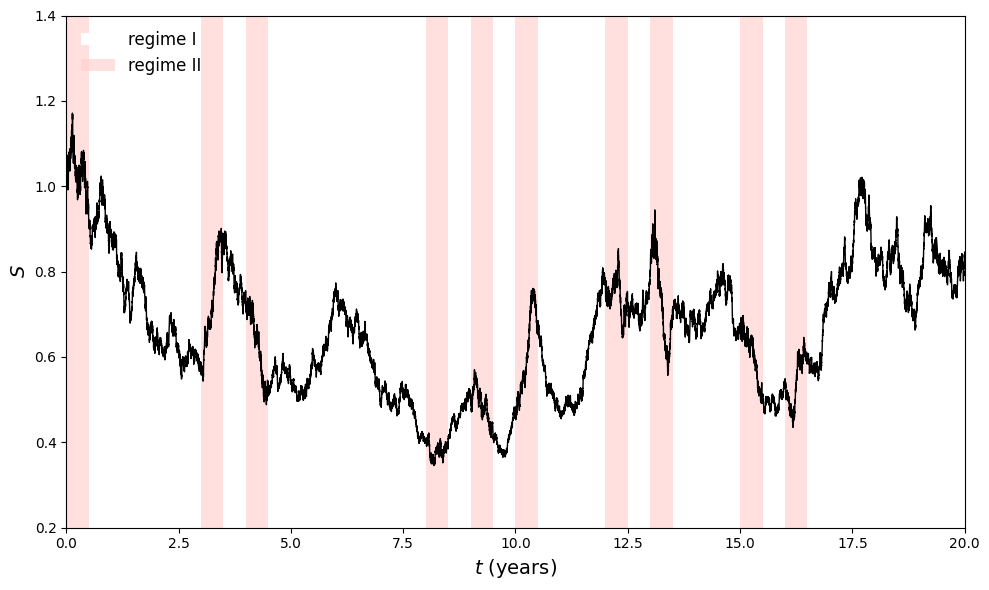

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def generate_synthetic_data(seed, n_years=20, steps_per_year=1764, n_regimes=10, regime_len=882):
    """Sinh chuỗi thời gian GBM giống hệt cấu trúc bài báo"""
    rng = np.random.default_rng(seed)
    n_steps = n_years * steps_per_year
    dt = 1.0 / steps_per_year
    
    # 1. Khởi tạo mảng Regime (0: Bull, 1: Bear)
    regimes = np.zeros(n_steps, dtype=int)
    
    # Tìm các điểm bắt đầu đợt Bear (không được đè lên nhau)
    available_starts = list(range(0, n_steps - regime_len * 2, regime_len * 2))
    # Chốt seed để bốc ngẫu nhiên vị trí
    if len(available_starts) >= n_regimes:
        bear_starts = sorted(rng.choice(available_starts, size=n_regimes, replace=False))
    else:
        bear_starts = available_starts
        
    for start in bear_starts:
        regimes[start : start + regime_len] = 1
        
    # 2. Sinh chuỗi giá
    log_prices = np.zeros(n_steps + 1)
    # Tác giả bài báo bắt đầu ở giá trị xấp xỉ 1.0
    log_prices[0] = np.log(1.0) 
    
    for t in range(n_steps):
        if regimes[t] == 0:
            mu, sigma = 0.02, 0.2  # Bull
        else:
            mu, sigma = -0.02, 0.3 # Bear
            
        dW = rng.normal(0, np.sqrt(dt))
        log_prices[t+1] = log_prices[t] + (mu - 0.5 * sigma**2) * dt + sigma * dW
        
    prices = np.exp(log_prices)
    times = np.linspace(0, n_years, n_steps + 1)
    
    return times, prices, regimes

def hunt_for_seed(max_seeds=10000):
    """Tìm Seed có hình dáng giống ảnh nhất"""
    print(f"Đang quét {max_seeds} seeds để tìm biểu đồ giống hình...")
    
    for seed in range(max_seeds):
        times, prices, _ = generate_synthetic_data(seed)
        
        min_price = np.min(prices)
        min_time = times[np.argmin(prices)]
        end_price = prices[-1]
        
        # ĐIỀU KIỆN KHỚP VỚI ẢNH (Có thể tinh chỉnh độ dung sai)
        # 1. Đáy ở khoảng năm 7.5 đến 8.5
        # 2. Giá trị đáy khoảng 0.3 đến 0.4
        # 3. Kết thúc ở mức xấp xỉ 1.0 (từ 0.8 đến 1.2)
        if (7.5 < min_time < 8.5) and (0.3 < min_price < 0.4) and (0.8 < end_price < 1.2):
            print(f"🎉 Đã tìm thấy Seed tiềm năng: {seed}")
            print(f" - Đáy: {min_price:.2f} tại năm {min_time:.2f}")
            print(f" - Giá kết thúc: {end_price:.2f}")
            return seed
            
    print("Không tìm thấy seed nào thỏa mãn trong khoảng này. Hãy tăng max_seeds.")
    return None

def plot_paper_style(seed):
    """Vẽ biểu đồ giống hệt phong cách của hình (a) trong bài báo"""
    times, prices, regimes = generate_synthetic_data(seed)
    
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Vẽ đường giá
    ax.plot(times, prices, color='black', linewidth=1)
    
    # Tô màu nền hồng cho các giai đoạn Bear (Regime II)
    in_bear = False
    start_bear = 0
    for i in range(len(regimes)):
        if regimes[i] == 1 and not in_bear:
            start_bear = times[i]
            in_bear = True
        elif regimes[i] == 0 and in_bear:
            # Vẽ dải nền hồng (salmon/mistyrose)
            ax.axvspan(start_bear, times[i], color='#ffcccb', alpha=0.6, lw=0)
            in_bear = False
            
    # Xử lý đoạn Bear ở cuối mảng (nếu có)
    if in_bear:
        ax.axvspan(start_bear, times[-1], color='#ffcccb', alpha=0.6, lw=0)

    # Decorate trục giống ảnh
    ax.set_xlim(0, 20)
    ax.set_ylim(0.2, 1.4)
    ax.set_xlabel('$t$ (years)', fontsize=14)
    ax.set_ylabel('$S$', fontsize=14)
    
    # Thêm Legend giả giống hình
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='white', label='regime I'),
        Patch(facecolor='#ffcccb', alpha=0.6, label='regime II')
    ]
    ax.legend(handles=legend_elements, loc='upper left', fontsize=12, frameon=False)
    
    plt.tight_layout()
    plt.show()

# ================= KỊCH BẢN CHẠY =================
# 1. Tìm seed (chạy mất khoảng vài chục giây)
best_seed = hunt_for_seed(max_seeds=20000)

# 2. Vẽ biểu đồ nếu tìm thấy
if best_seed is not None:
    plot_paper_style(best_seed)

ValueError: 'c' argument has 35279 elements, which is inconsistent with 'x' and 'y' with size 35280.

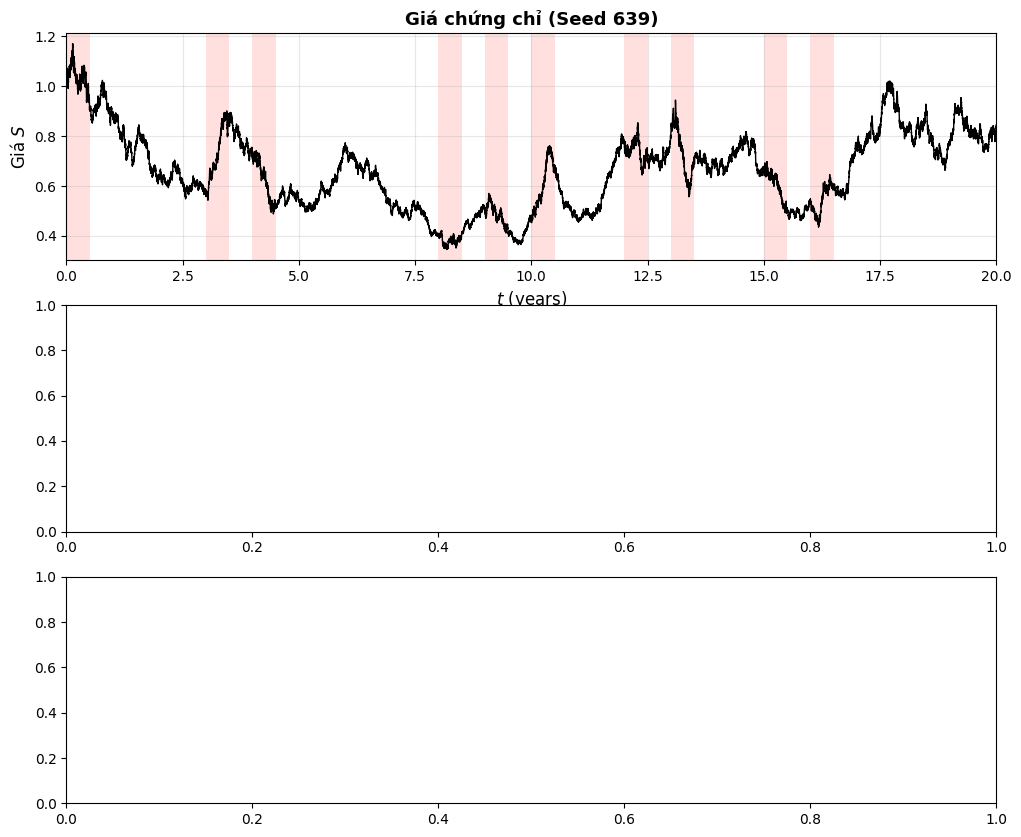